# Proyecto Final IA: Robot asistente hospitalario


La idea central es comparar dos enfoques para la toma de decisiones del robot:

- **Value Iteration:** método basado en modelo. Conoce las transiciones del MDP y calcula una política usando la ecuación de Bellman.
- **Q-Learning:** método model-free. No conoce el modelo completo; aprende por experiencia mediante episodios.

> Objetivo del notebook: ejecutar ambos enfoques bajo el mismo entorno y generar analisis comparativo de sus resultados.

## 1. Configuración inicial

Esta sección prepara rutas, librerías y carpetas de resultados. También usa una semilla aleatoria para que las corridas sean más comparables.


In [46]:
from pathlib import Path
import sys
import random
import subprocess
import time

import pandas as pd
import matplotlib.pyplot as plt

# Semilla para que las pruebas sean más comparables
random.seed(42)


def find_project_root(start=None):
    """
    Busca automáticamente la raíz del proyecto.
    La raíz debe contener las carpetas src/ y tests/.
    """
    start = Path(start or Path.cwd()).resolve()

    for path in [start, *start.parents]:
        if (path / "src").exists() and (path / "tests").exists():
            return path

    raise FileNotFoundError(
        "No se encontró la raíz del proyecto. "
        "Asegúrate de abrir el notebook dentro del repositorio IA_Proyecto_Final."
    )


ROOT = find_project_root()

SRC_DIR = ROOT / "src"
TESTS_DIR = ROOT / "tests"
RESULTS_DIR = ROOT / "results"
PLOTS_DIR = RESULTS_DIR / "plots"
TABLES_DIR = RESULTS_DIR / "tables"

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

# Permite importar src.environment, src.q_learning, etc.
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("Raíz del proyecto:", ROOT)
print("Carpeta de gráficas:", PLOTS_DIR.relative_to(ROOT))
print("Carpeta de tablas:", TABLES_DIR.relative_to(ROOT))

Raíz del proyecto: /home/ricgo/2026_S1/IA/IA_Proyecto_Final
Carpeta de gráficas: results/plots
Carpeta de tablas: results/tables


## 2. Importación de módulos del proyecto

Aquí se importan los archivos principales desarrollados en `src/`:

- `environment.py`: define el hospital, estados, acciones, batería y recompensas.
- `value_iteration.py`: calcula la política óptima usando Bellman.
- `q_learning.py`: entrena al agente por experiencia.
- `metrics.py`: evalúa y compara resultados.

In [47]:
from src.environment import (
    HospitalEnvironment,
    Action,
    START_POS,
    GOAL_POS,
    CHARGE_POS,
    MAX_BATTERY,
    HOSPITAL_MAP,
    W,
    P,
    S,
    G,
    C,
    R,
    Z,
)
from src.metrics import evaluate_agent, compare_agents, save_results_table
from src.experiments import (
    train_value_iteration,
    train_q_learning,
    evaluate_model,
    Q_LEARNING_CONFIGS,
    run_q_experiment,
)

In [48]:
METRICS_HIGHER = ["% entregas exitosas", "Recompensa acumulada promedio"]
METRICS_LOWER  = ["Tiempo promedio de entrega", "Consumo promedio de batería", "Fallos de misión"]
SCORE_COLS     = ["Éxito normalizado", "Recompensa normalizada", "Batería normalizada",
                  "Fallos normalizados", "Puntaje general"]


def styled_table(df, caption=None):
    """Muestra un DataFrame con gradientes de color: verde=mejor, rojo=peor."""
    fmt = {}
    for col in df.select_dtypes(include="number").columns:
        fmt[col] = "{:.1f}%" if "%" in col else "{:.2f}"

    s = df.style

    higher = [c for c in METRICS_HIGHER + SCORE_COLS if c in df.columns]
    lower  = [c for c in METRICS_LOWER  if c in df.columns]
    if higher:
        s = s.background_gradient(cmap="RdYlGn", subset=higher, axis=0)
    if lower:
        s = s.background_gradient(cmap="RdYlGn_r", subset=lower, axis=0)

    s = s.format(fmt).set_properties(**{"text-align": "center"})

    if caption:
        s = s.set_caption(caption).set_table_styles([
            {"selector": "caption", "props": [
                ("font-size", "14px"), ("font-weight", "bold"),
                ("color", "#1f2937"), ("text-align", "left"), ("padding-bottom", "6px"),
            ]},
        ])
    return s

## 4. Validación rápida del entorno

Esta sección revisa que el entorno inicial tenga sentido:

- El robot inicia en `(1, 1)`.
- El destino está en `(10, 14)`.
- La batería máxima es 30.
- Las acciones iniciales disponibles son movimiento y espera.

In [49]:
env_check = HospitalEnvironment()
initial_state = env_check.reset()
initial_actions = [a.name for a in env_check.get_possible_actions(initial_state)]

print("Estado inicial:", initial_state)
print("Posición inicial esperada:", START_POS)
print("Destino:", GOAL_POS)
print("Estación de carga:", CHARGE_POS)
print("Batería máxima:", MAX_BATTERY)
print("Acciones posibles al inicio:", initial_actions)

Estado inicial: (1, 1, 30)
Posición inicial esperada: (1, 1)
Destino: (10, 14)
Estación de carga: (5, 5)
Batería máxima: 30
Acciones posibles al inicio: ['UP', 'DOWN', 'LEFT', 'RIGHT', 'STAY']


## 5. Visualización del mapa del hospital

La visualización ayuda a explicar el problema. El hospital se representa como un GridWorld:

- Paredes: zonas no transitables.
- Pasillos: zonas normales.
- Zonas congestionadas: penalización moderada.
- Zonas de riesgo: penalización alta.
- Estación de carga: permite recuperar batería.
- Inicio y destino: puntos clave de la misión.

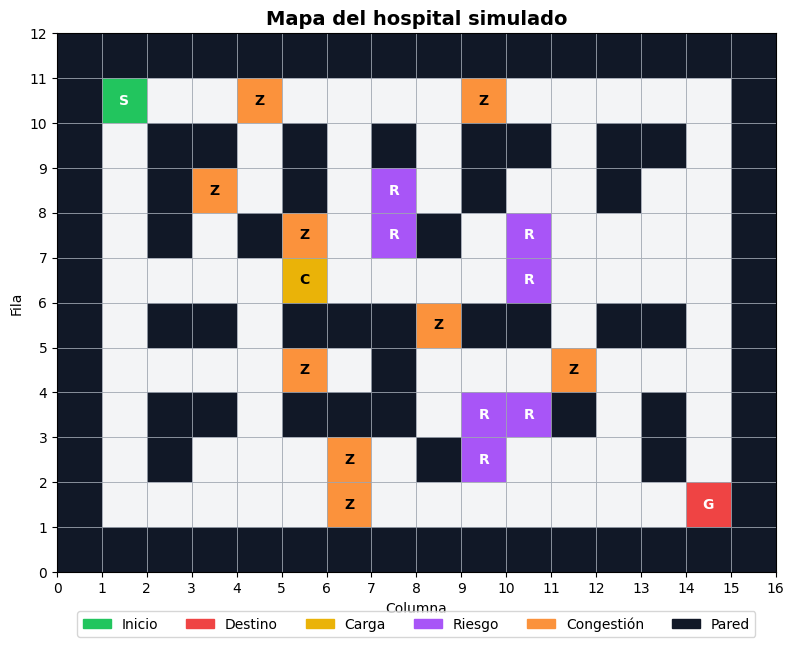

In [50]:
def plot_hospital_map(save=True):
    color_map = {
        W: "#111827",  # pared
        P: "#f3f4f6",  # pasillo
        S: "#22c55e",  # inicio
        G: "#ef4444",  # destino
        C: "#eab308",  # carga
        R: "#a855f7",  # riesgo
        Z: "#fb923c",  # congestión
    }

    label_map = {
        W: "",
        P: "",
        S: "S",
        G: "G",
        C: "C",
        R: "R",
        Z: "Z",
    }

    rows = len(HOSPITAL_MAP)
    cols = len(HOSPITAL_MAP[0])

    fig, ax = plt.subplots(figsize=(12, 7))

    for r in range(rows):
        for c in range(cols):
            cell = HOSPITAL_MAP[r][c]
            rect = plt.Rectangle(
                (c, rows - r - 1),
                1,
                1,
                facecolor=color_map[cell],
                edgecolor="#9ca3af",
                linewidth=0.5,
            )
            ax.add_patch(rect)
            label = label_map[cell]
            if label:
                ax.text(
                    c + 0.5,
                    rows - r - 0.5,
                    label,
                    ha="center",
                    va="center",
                    fontsize=10,
                    fontweight="bold",
                    color="white" if cell in [S, G, R, W] else "black",
                )

    ax.set_xlim(0, cols)
    ax.set_ylim(0, rows)
    ax.set_aspect("equal")
    ax.set_xticks(range(cols + 1))
    ax.set_yticks(range(rows + 1))
    ax.grid(False)
    ax.set_title("Mapa del hospital simulado", fontsize=14, fontweight="bold")
    ax.set_xlabel("Columna")
    ax.set_ylabel("Fila")

    legend_items = [
        ("Inicio", "#22c55e"),
        ("Destino", "#ef4444"),
        ("Carga", "#eab308"),
        ("Riesgo", "#a855f7"),
        ("Congestión", "#fb923c"),
        ("Pared", "#111827"),
    ]
    handles = [plt.Rectangle((0, 0), 1, 1, color=color) for _, color in legend_items]
    labels = [label for label, _ in legend_items]
    ax.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, -0.06), ncol=6)

    if save:
        plt.savefig(PLOTS_DIR / "mapa_hospital.png", bbox_inches="tight", dpi=150)

    plt.show()

plot_hospital_map()

## 6. Ejecución de Value Iteration

Value Iteration calcula una política a partir del MDP. Este método conoce el modelo de transición del entorno, por eso suele ser más estable cuando el modelo está bien definido.

La política resultante indica qué acción debe tomar el robot en cada estado.

In [29]:
env_vi = HospitalEnvironment()

start_time = time.time()
vi_agent = train_value_iteration(env_vi, gamma=0.9, theta=1e-3, verbose=True)
vi_elapsed = time.time() - start_time

start_state = env_vi.reset()
vi_start_action = vi_agent.get_action(start_state)

print("Iteraciones Value Iteration:", vi_agent.iterations)
print(f"Tiempo de ejecución Value Iteration: {vi_elapsed:.2f} segundos")
print("Acción recomendada al inicio:", vi_start_action.name if vi_start_action is not None else None)
print("Estados con política:", len(vi_agent.policy))

Iter   10  Δ = 19.371024
Iter   20  Δ = 2.927521
Iter   30  Δ = 0.306108
Iter   40  Δ = 0.083290
Iter   50  Δ = 0.001963
Convergió en 52 iteraciones (Δ = 0.000942)
Iteraciones Value Iteration: 52
Tiempo de ejecución Value Iteration: 4.98 segundos
Acción recomendada al inicio: DOWN
Estados con política: 3120


## 7. Entrenamiento base de Q-Learning

Q-Learning aprende por experiencia. Al inicio explora mucho y puede fallar, pero conforme acumula episodios va ajustando su Q-table.

En este notebook se prueba primero una configuración base. Luego se comparan varias configuraciones para analizar si Q-Learning mejora con más entrenamiento.

In [30]:
env_ql_base = HospitalEnvironment()
QL_BASE_EPISODES = 50_000

start_time = time.time()
ql_base = train_q_learning(env_ql_base, episodes=QL_BASE_EPISODES, alpha=0.1, gamma=0.95, epsilon=0.3, max_steps=200, seed=42)
ql_base_elapsed = time.time() - start_time

start_state = env_ql_base.reset()
ql_start_action = ql_base.get_action(start_state)

print("Episodios entrenados:", len(ql_base.rewards_per_episode))
print(f"Tiempo de entrenamiento Q-Learning base: {ql_base_elapsed:.2f} segundos")
print("Estados aprendidos en Q-table:", len(ql_base.Q))
print("Acción recomendada al inicio:", ql_start_action.name if ql_start_action is not None else None)

Episodios entrenados: 50000
Tiempo de entrenamiento Q-Learning base: 10.87 segundos
Estados aprendidos en Q-table: 2419
Acción recomendada al inicio: DOWN


## 8. Curva de aprendizaje de Q-Learning

Esta gráfica muestra la recompensa acumulada por episodio.

La línea clara representa la recompensa episodio por episodio, que puede variar bastante por la estocasticidad del entorno. La línea azul fuerte usa un promedio móvil para observar mejor la tendencia.

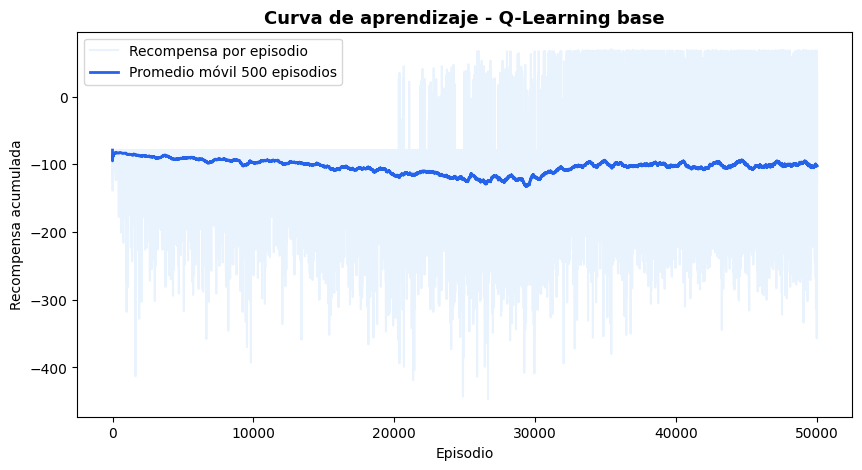

In [31]:
rewards = pd.Series(ql_base.rewards_per_episode)
rolling_rewards = rewards.rolling(window=500, min_periods=1).mean()

plt.figure(figsize=(10, 5))
plt.plot(rewards, alpha=0.20, color="#93c5fd", label="Recompensa por episodio")
plt.plot(rolling_rewards, color="#2563eb", linewidth=2, label="Promedio móvil 500 episodios")
plt.title("Curva de aprendizaje - Q-Learning base", fontsize=13, fontweight="bold")
plt.xlabel("Episodio")
plt.ylabel("Recompensa acumulada")
plt.legend()
plt.savefig(PLOTS_DIR / "q_learning_rewards_base.png", bbox_inches="tight", dpi=150)
plt.show()

## 9. Evaluación principal: Value Iteration vs Q-Learning base

Ambos agentes se evalúan bajo el mismo entorno y el mismo número de episodios.

Métricas utilizadas:

- Tiempo promedio de entrega.
- Consumo promedio de batería.
- Porcentaje de entregas exitosas.
- Recompensa acumulada promedio.
- Fallos de misión.

In [32]:
EVAL_EPISODES = 100
EVAL_MAX_STEPS = 200

random.seed(123)
results_vi = evaluate_agent(
    env_vi,
    vi_agent,
    episodes=EVAL_EPISODES,
    max_steps=EVAL_MAX_STEPS,
    agent_name="Value Iteration",
)

random.seed(123)
results_ql_base = evaluate_agent(
    env_ql_base,
    ql_base,
    episodes=EVAL_EPISODES,
    max_steps=EVAL_MAX_STEPS,
    agent_name="Q-Learning base",
)

comparison = compare_agents(results_vi, results_ql_base)
comparison_clean = comparison.copy()
comparison_clean["Tiempo promedio de entrega"] = comparison_clean["Tiempo promedio de entrega"].round(2)
comparison_clean["Consumo promedio de batería"] = comparison_clean["Consumo promedio de batería"].round(2)
comparison_clean["% entregas exitosas"] = comparison_clean["% entregas exitosas"].round(1)
comparison_clean["Recompensa acumulada promedio"] = comparison_clean["Recompensa acumulada promedio"].round(2)

styled_table(comparison_clean, "Métricas comparativas: Value Iteration vs Q-Learning base")

,Agente,Episodios,Tiempo promedio de entrega,Consumo promedio de batería,% entregas exitosas,Recompensa acumulada promedio,Fallos de misión
0,Value Iteration,100.00,28.98,26.00,90.0%,48.60,10.00
1,Q-Learning base,100.00,30.98,29.55,66.0%,11.16,34.00


## 10. Guardado de tablas principales

Se guardan los resultados en `results/tables/` para que puedan usarse en el informe y presentación.

In [33]:
save_results_table(comparison_clean, TABLES_DIR / "metricas_comparativas.csv")

results_vi["details"].to_csv(
    TABLES_DIR / "detalle_value_iteration.csv",
    index=False,
    encoding="utf-8-sig",
)

results_ql_base["details"].to_csv(
    TABLES_DIR / "detalle_q_learning_base.csv",
    index=False,
    encoding="utf-8-sig",
)

print("Tablas guardadas en:", TABLES_DIR)

display(styled_table(comparison_clean, "Resumen: métricas guardadas"))
display(styled_table(
    results_vi["details"].describe().T.reset_index().rename(columns={"index": "Métrica"}),
    "Detalle estadístico — Value Iteration",
))
display(styled_table(
    results_ql_base["details"].describe().T.reset_index().rename(columns={"index": "Métrica"}),
    "Detalle estadístico — Q-Learning base",
))

Tablas guardadas en: /home/ricgo/2026_S1/IA/IA_Proyecto_Final/results/tables


,Agente,Episodios,Tiempo promedio de entrega,Consumo promedio de batería,% entregas exitosas,Recompensa acumulada promedio,Fallos de misión
0,Value Iteration,100.00,28.98,26.00,90.0%,48.60,10.00
1,Q-Learning base,100.00,30.98,29.55,66.0%,11.16,34.00


,Métrica,count,mean,std,min,25%,50%,75%,max
0,episode,100.00,50.50,29.01,1.00,25.8%,50.5%,75.2%,100.00
1,steps,100.00,29.08,5.39,22.00,25.8%,28.0%,30.0%,51.00
2,total_reward,100.00,48.60,48.62,-106.00,51.8%,67.5%,71.0%,75.00
3,battery_consumed,100.00,26.00,3.35,16.00,24.0%,26.0%,29.0%,30.00


,Métrica,count,mean,std,min,25%,50%,75%,max
0,episode,100.00,50.50,29.01,1.00,25.8%,50.5%,75.2%,100.00
1,steps,100.00,31.09,5.59,29.00,29.0%,30.0%,30.0%,63.00
2,total_reward,100.00,11.16,74.71,-139.00,-83.0%,63.0%,68.0%,68.00
3,battery_consumed,100.00,29.55,0.50,29.00,29.0%,30.0%,30.0%,30.00


## 11. Gráficas comparativas principales

Estas gráficas comparan directamente Value Iteration contra Q-Learning base.

Colores utilizados:

- Naranja: Value Iteration.
- Azul: Q-Learning.

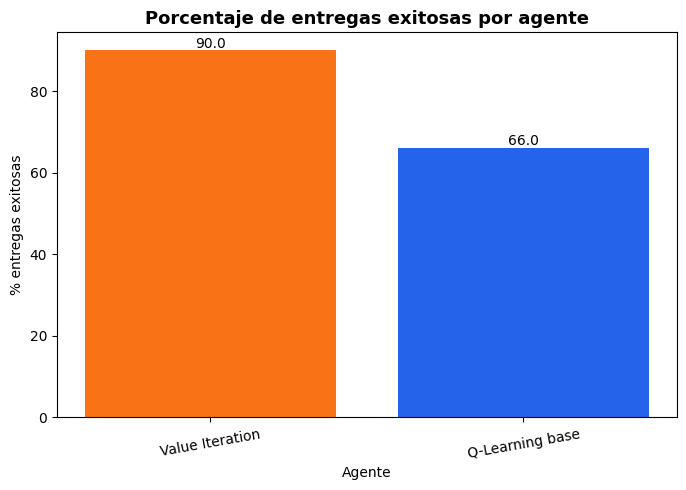

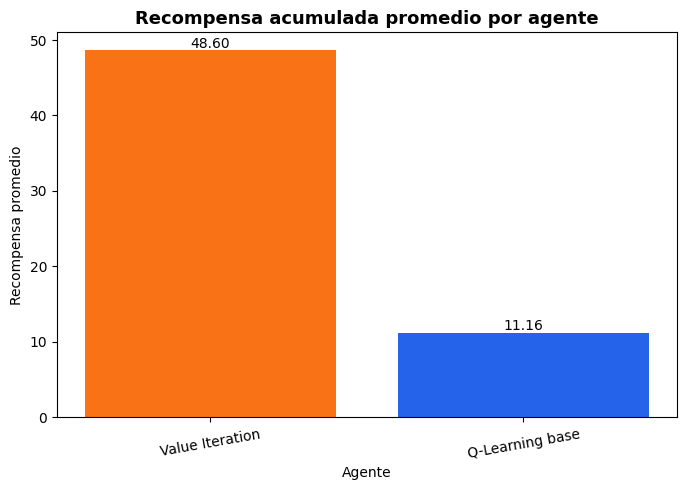

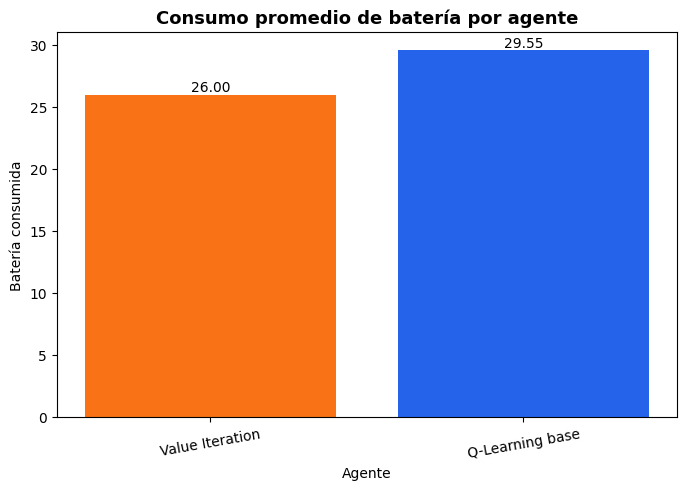

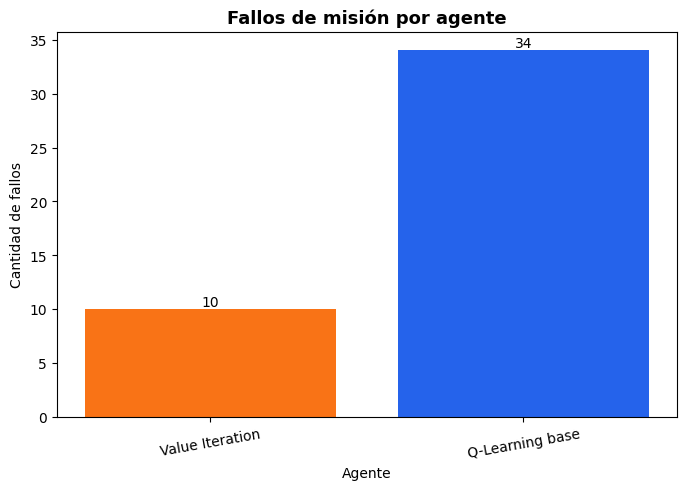

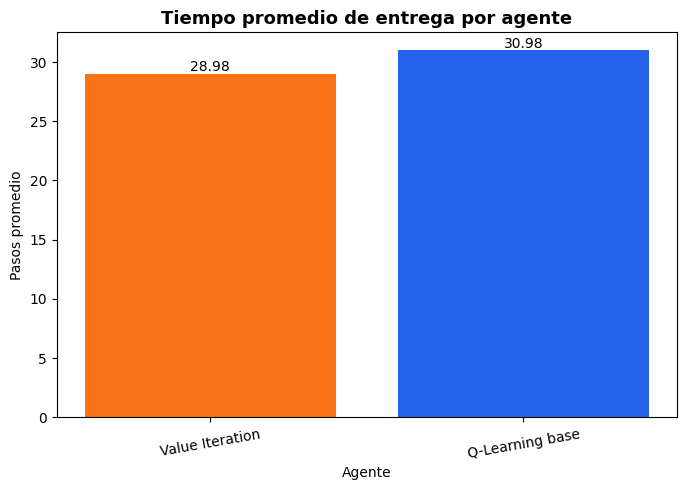

In [34]:
agent_colors = {
    "Value Iteration": "#f97316",
    "Q-Learning base": "#2563eb",
    "Q-Learning más episodios": "#1d4ed8",
    "Q-Learning gamma alto": "#0ea5e9",
    "Q-Learning epsilon decay": "#14b8a6",
}

def save_bar_chart(data, column, title, ylabel, filename, decimals=2):
    values = data[column].fillna(0)
    colors = [agent_colors.get(agent, "#6b7280") for agent in data["Agente"]]

    plt.figure(figsize=(8, 5))
    bars = plt.bar(data["Agente"], values, color=colors)

    plt.title(title, fontsize=13, fontweight="bold")
    plt.ylabel(ylabel)
    plt.xlabel("Agente")
    plt.xticks(rotation=10)

    for bar, value in zip(bars, values):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{value:.{decimals}f}",
            ha="center",
            va="bottom",
            fontsize=10,
        )

    plt.savefig(PLOTS_DIR / filename, bbox_inches="tight", dpi=150)
    plt.show()

save_bar_chart(
    comparison_clean,
    "% entregas exitosas",
    "Porcentaje de entregas exitosas por agente",
    "% entregas exitosas",
    "entregas_exitosas.png",
    decimals=1,
)

save_bar_chart(
    comparison_clean,
    "Recompensa acumulada promedio",
    "Recompensa acumulada promedio por agente",
    "Recompensa promedio",
    "recompensa_promedio.png",
    decimals=2,
)

save_bar_chart(
    comparison_clean,
    "Consumo promedio de batería",
    "Consumo promedio de batería por agente",
    "Batería consumida",
    "consumo_bateria.png",
    decimals=2,
)

save_bar_chart(
    comparison_clean,
    "Fallos de misión",
    "Fallos de misión por agente",
    "Cantidad de fallos",
    "fallos_mision.png",
    decimals=0,
)

save_bar_chart(
    comparison_clean,
    "Tiempo promedio de entrega",
    "Tiempo promedio de entrega por agente",
    "Pasos promedio",
    "tiempo_entrega.png",
    decimals=2,
)

## 12. Ganador por métrica

Esta tabla resume qué algoritmo obtuvo mejor resultado en cada métrica.

- En tiempo, batería y fallos: menor es mejor.
- En éxito y recompensa: mayor es mejor.

In [35]:
vi = comparison_clean[comparison_clean["Agente"] == "Value Iteration"].iloc[0]
ql = comparison_clean[comparison_clean["Agente"] == "Q-Learning base"].iloc[0]

winner_rows = [
    {
        "Métrica": "Tiempo promedio de entrega",
        "Mejor resultado": "Menor",
        "Ganador": "Value Iteration" if vi["Tiempo promedio de entrega"] < ql["Tiempo promedio de entrega"] else "Q-Learning base",
    },
    {
        "Métrica": "Consumo promedio de batería",
        "Mejor resultado": "Menor",
        "Ganador": "Value Iteration" if vi["Consumo promedio de batería"] < ql["Consumo promedio de batería"] else "Q-Learning base",
    },
    {
        "Métrica": "% entregas exitosas",
        "Mejor resultado": "Mayor",
        "Ganador": "Value Iteration" if vi["% entregas exitosas"] > ql["% entregas exitosas"] else "Q-Learning base",
    },
    {
        "Métrica": "Recompensa acumulada promedio",
        "Mejor resultado": "Mayor",
        "Ganador": "Value Iteration" if vi["Recompensa acumulada promedio"] > ql["Recompensa acumulada promedio"] else "Q-Learning base",
    },
    {
        "Métrica": "Fallos de misión",
        "Mejor resultado": "Menor",
        "Ganador": "Value Iteration" if vi["Fallos de misión"] < ql["Fallos de misión"] else "Q-Learning base",
    },
]

winner_table = pd.DataFrame(winner_rows)
winner_table.to_csv(TABLES_DIR / "ganador_por_metrica.csv", index=False, encoding="utf-8-sig")

AGENT_COLORS_HEX = {
    "Value Iteration": "#fdba74",
    "Q-Learning base": "#93c5fd",
}

def highlight_winner(row):
    color = AGENT_COLORS_HEX.get(row["Ganador"], "#e5e7eb")
    return ["", "", f"background-color: {color}; font-weight: bold"]

winner_table.style \
    .apply(highlight_winner, axis=1) \
    .set_caption("Ganador por métrica") \
    .set_table_styles([
        {"selector": "caption", "props": [
            ("font-size", "14px"), ("font-weight", "bold"),
            ("color", "#1f2937"), ("text-align", "left"), ("padding-bottom", "6px"),
        ]},
    ]) \
    .set_properties(**{"text-align": "center"})

,Métrica,Mejor resultado,Ganador
0,Tiempo promedio de entrega,Menor,Value Iteration
1,Consumo promedio de batería,Menor,Value Iteration
2,% entregas exitosas,Mayor,Value Iteration
3,Recompensa acumulada promedio,Mayor,Value Iteration
4,Fallos de misión,Menor,Value Iteration


## 13. Pruebas adicionales con Q-Learning

Esta sección busca responder una pregunta interesante para el proyecto:

> ¿Puede Q-Learning mejorar si se entrena más o si se ajustan sus parámetros?

Se prueban varias configuraciones. Esto no garantiza que Q-Learning supere a Value Iteration, porque Value Iteration calcula una política usando el modelo conocido del entorno. Sin embargo, Q-Learning puede acercarse o mejorar respecto a su versión base si recibe más entrenamiento.

Configuraciones probadas:

1. **Más episodios:** más experiencia para aprender.
2. **Gamma alto:** da más importancia a recompensas futuras, útil cuando el destino está lejos.
3. **Epsilon decay:** explora bastante al inicio y luego explota lo aprendido.

### Configuraciones de prueba

Para una prueba rápida se pueden bajar los episodios. Para resultados finales, conviene dejar valores altos.

Si tu computadora tarda demasiado, reduce `episodes` en las configuraciones.

In [36]:
q_experiment_configs = Q_LEARNING_CONFIGS[1:]  # omite "Q-Learning base", ya entrenado arriba

q_experiment_configs

[{'name': 'Q-Learning más episodios',
  'type': 'standard',
  'episodes': 80000,
  'alpha': 0.1,
  'gamma': 0.95,
  'epsilon': 0.3,
  'seed': 44},
 {'name': 'Q-Learning gamma alto',
  'type': 'standard',
  'episodes': 80000,
  'alpha': 0.1,
  'gamma': 0.98,
  'epsilon': 0.3,
  'seed': 45},
 {'name': 'Q-Learning más explotación',
  'type': 'standard',
  'episodes': 80000,
  'alpha': 0.1,
  'gamma': 0.98,
  'epsilon': 0.15,
  'seed': 46},
 {'name': 'Q-Learning epsilon decay',
  'type': 'decay',
  'episodes': 80000,
  'alpha': 0.1,
  'gamma': 0.95,
  'epsilon_start': 0.7,
  'epsilon_end': 0.05,
  'seed': 47}]

### Ejecución de pruebas adicionales

Esta celda entrena varios agentes de Q-Learning y los evalúa. Puede tardar un poco porque cada configuración requiere muchos episodios.

In [37]:
q_experiment_results = []
q_experiment_agents = {}
q_experiment_envs = {}
q_training_times = {}

for config in q_experiment_configs:
    print(f"Entrenando: {config['name']}...")

    env_exp = HospitalEnvironment()
    start = time.time()
    agent_exp = run_q_experiment(config, env_exp)
    elapsed = time.time() - start

    result = evaluate_model(env_exp, agent_exp, name=config["name"], episodes=EVAL_EPISODES, max_steps=EVAL_MAX_STEPS)

    q_experiment_results.append(result)
    q_experiment_agents[config["name"]] = agent_exp
    q_experiment_envs[config["name"]] = env_exp
    q_training_times[config["name"]] = elapsed

    print(f"  Tiempo entrenamiento: {elapsed:.2f} segundos")
    print(f"  Éxito: {result['success_rate']:.1f}% | Recompensa promedio: {result['avg_reward']:.2f}")
    print()

Entrenando: Q-Learning más episodios...
  Tiempo entrenamiento: 16.23 segundos
  Éxito: 67.0% | Recompensa promedio: 11.35

Entrenando: Q-Learning gamma alto...
  Tiempo entrenamiento: 17.42 segundos
  Éxito: 77.0% | Recompensa promedio: 25.17

Entrenando: Q-Learning más explotación...
  Tiempo entrenamiento: 15.54 segundos
  Éxito: 73.0% | Recompensa promedio: 18.04

Entrenando: Q-Learning epsilon decay...
  Tiempo entrenamiento: 15.76 segundos
  Éxito: 66.0% | Recompensa promedio: 10.67



## 14. Comparación completa: Value Iteration vs varias versiones de Q-Learning

Aquí se compara Value Iteration con todas las configuraciones de Q-Learning probadas.

In [38]:
all_results = [results_vi, results_ql_base] + q_experiment_results
full_comparison = compare_agents(*all_results)

full_comparison_clean = full_comparison.copy()
full_comparison_clean["Tiempo promedio de entrega"] = full_comparison_clean["Tiempo promedio de entrega"].round(2)
full_comparison_clean["Consumo promedio de batería"] = full_comparison_clean["Consumo promedio de batería"].round(2)
full_comparison_clean["% entregas exitosas"] = full_comparison_clean["% entregas exitosas"].round(1)
full_comparison_clean["Recompensa acumulada promedio"] = full_comparison_clean["Recompensa acumulada promedio"].round(2)

full_comparison_clean.to_csv(TABLES_DIR / "comparacion_completa_agentes.csv", index=False, encoding="utf-8-sig")

styled_table(full_comparison_clean, "Comparación completa: todos los agentes")

,Agente,Episodios,Tiempo promedio de entrega,Consumo promedio de batería,% entregas exitosas,Recompensa acumulada promedio,Fallos de misión
0,Value Iteration,100.00,28.98,26.00,90.0%,48.60,10.00
1,Q-Learning base,100.00,30.98,29.55,66.0%,11.16,34.00
2,Q-Learning más episodios,100.00,31.75,29.19,67.0%,11.35,33.00
3,Q-Learning gamma alto,100.00,32.45,28.65,77.0%,25.17,23.00
4,Q-Learning más explotación,100.00,34.10,29.03,73.0%,18.04,27.00
5,Q-Learning epsilon decay,100.00,30.18,29.13,66.0%,10.67,34.00


## 15. Gráficas de comparación completa

Estas gráficas permiten ver si alguna configuración de Q-Learning se acerca o supera a la configuración base.

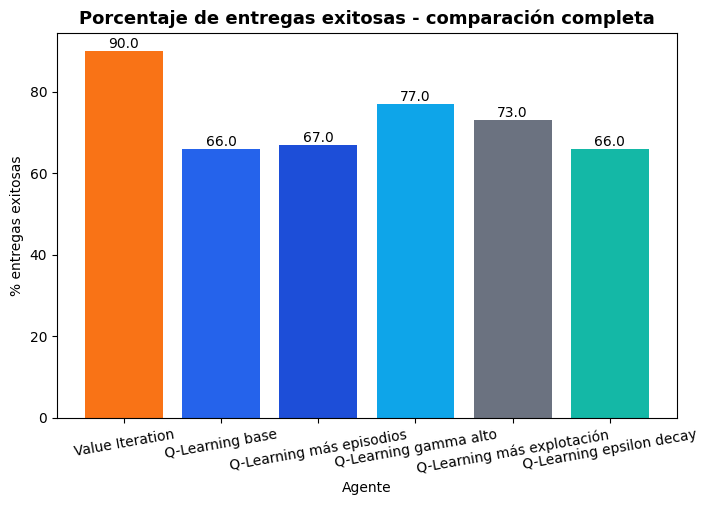

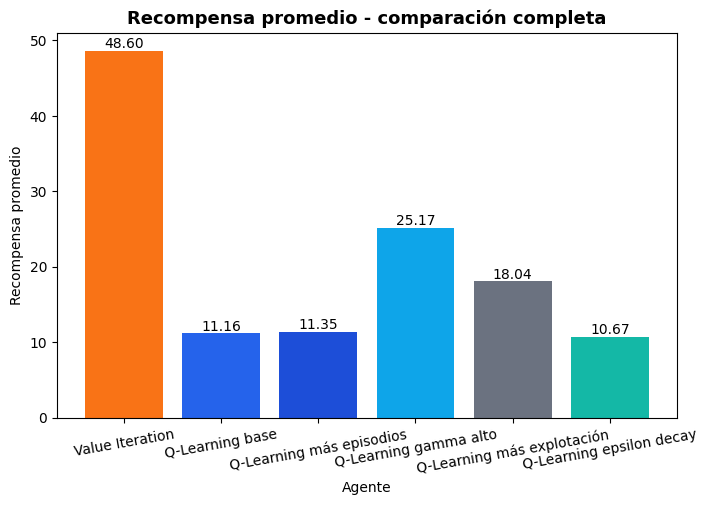

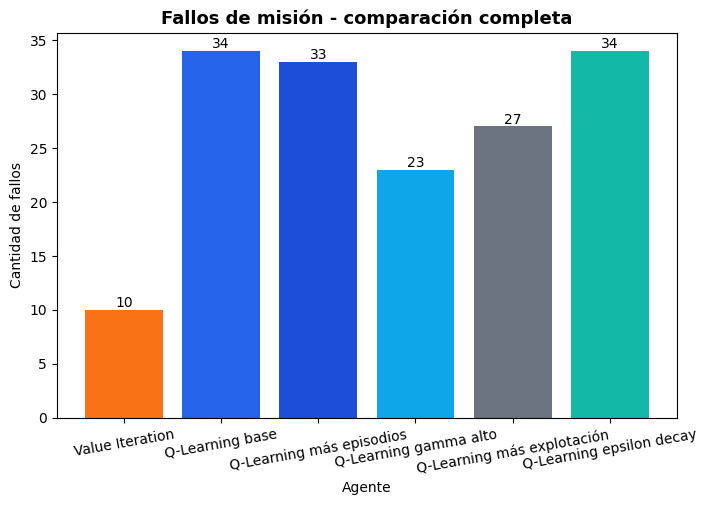

In [39]:
save_bar_chart(
    full_comparison_clean,
    "% entregas exitosas",
    "Porcentaje de entregas exitosas - comparación completa",
    "% entregas exitosas",
    "comparacion_completa_entregas_exitosas.png",
    decimals=1,
)

save_bar_chart(
    full_comparison_clean,
    "Recompensa acumulada promedio",
    "Recompensa promedio - comparación completa",
    "Recompensa promedio",
    "comparacion_completa_recompensa.png",
    decimals=2,
)

save_bar_chart(
    full_comparison_clean,
    "Fallos de misión",
    "Fallos de misión - comparación completa",
    "Cantidad de fallos",
    "comparacion_completa_fallos.png",
    decimals=0,
)

## 16. Mejor configuración de Q-Learning

En esta sección se identifica automáticamente cuál versión de Q-Learning tuvo mejor desempeño. Se prioriza:

1. Mayor porcentaje de entregas exitosas.
2. Mayor recompensa promedio.
3. Menor cantidad de fallos.

In [40]:
q_only = full_comparison_clean[full_comparison_clean["Agente"].str.contains("Q-Learning")].copy()

best_q = q_only.sort_values(
    by=["% entregas exitosas", "Recompensa acumulada promedio", "Fallos de misión"],
    ascending=[False, False, True],
).iloc[0]

vi_row = full_comparison_clean[full_comparison_clean["Agente"] == "Value Iteration"].iloc[0]

print("Mejor configuración de Q-Learning:")
print(best_q)
print()

if best_q["% entregas exitosas"] > vi_row["% entregas exitosas"]:
    print("En esta corrida, Q-Learning superó a Value Iteration en porcentaje de entregas exitosas.")
    print("Esto puede ocurrir por variación muestral o por la forma de evaluación estocástica, pero no implica necesariamente que Q-Learning sea óptimo.")
elif best_q["% entregas exitosas"] == vi_row["% entregas exitosas"]:
    print("La mejor versión de Q-Learning igualó a Value Iteration en porcentaje de entregas exitosas.")
    print("Esto muestra que con suficiente entrenamiento puede acercarse a una política fuerte.")
else:
    print("Value Iteration sigue obteniendo mayor porcentaje de entregas exitosas que la mejor versión de Q-Learning.")
    print("Esto es coherente porque Value Iteration conoce el modelo del entorno, mientras que Q-Learning aprende por experiencia.")

Mejor configuración de Q-Learning:
Agente                           Q-Learning gamma alto
Episodios                                          100
Tiempo promedio de entrega                       32.45
Consumo promedio de batería                      28.65
% entregas exitosas                               77.0
Recompensa acumulada promedio                    25.17
Fallos de misión                                    23
Name: 3, dtype: object

Value Iteration sigue obteniendo mayor porcentaje de entregas exitosas que la mejor versión de Q-Learning.
Esto es coherente porque Value Iteration conoce el modelo del entorno, mientras que Q-Learning aprende por experiencia.


## 17. Puntaje general normalizado

Para tener una comparación visual más resumida, se calcula un puntaje normalizado entre 0 y 1.

Este puntaje combina:

- Éxito normalizado.
- Recompensa normalizada.
- Batería normalizada.
- Fallos normalizados.

> Esta métrica no reemplaza las métricas reales. Solo sirve como resumen visual para presentación.

In [41]:
def minmax(series):
    min_value = series.min()
    max_value = series.max()
    if max_value == min_value:
        return pd.Series([1.0] * len(series), index=series.index)
    return (series - min_value) / (max_value - min_value)

normalized = full_comparison_clean.copy()
normalized["Éxito normalizado"] = normalized["% entregas exitosas"] / 100
normalized["Recompensa normalizada"] = minmax(normalized["Recompensa acumulada promedio"])
normalized["Batería normalizada"] = 1 - minmax(normalized["Consumo promedio de batería"])
normalized["Fallos normalizados"] = 1 - minmax(normalized["Fallos de misión"])

summary_score = normalized[
    [
        "Agente",
        "Éxito normalizado",
        "Recompensa normalizada",
        "Batería normalizada",
        "Fallos normalizados",
    ]
].copy()

summary_score["Puntaje general"] = summary_score[
    [
        "Éxito normalizado",
        "Recompensa normalizada",
        "Batería normalizada",
        "Fallos normalizados",
    ]
].mean(axis=1)

summary_score = summary_score.sort_values("Puntaje general", ascending=False)
summary_score.to_csv(TABLES_DIR / "puntaje_general_normalizado.csv", index=False, encoding="utf-8-sig")

styled_table(summary_score, "Puntaje general normalizado por agente (1 = mejor)")

,Agente,Éxito normalizado,Recompensa normalizada,Batería normalizada,Fallos normalizados,Puntaje general
0,Value Iteration,0.90,1.00,1.00,1.00,0.97
3,Q-Learning gamma alto,0.77,0.38,0.25,0.46,0.47
4,Q-Learning más explotación,0.73,0.19,0.15,0.29,0.34
2,Q-Learning más episodios,0.67,0.02,0.10,0.04,0.21
5,Q-Learning epsilon decay,0.66,0.00,0.12,0.00,0.19
1,Q-Learning base,0.66,0.01,0.00,0.00,0.17


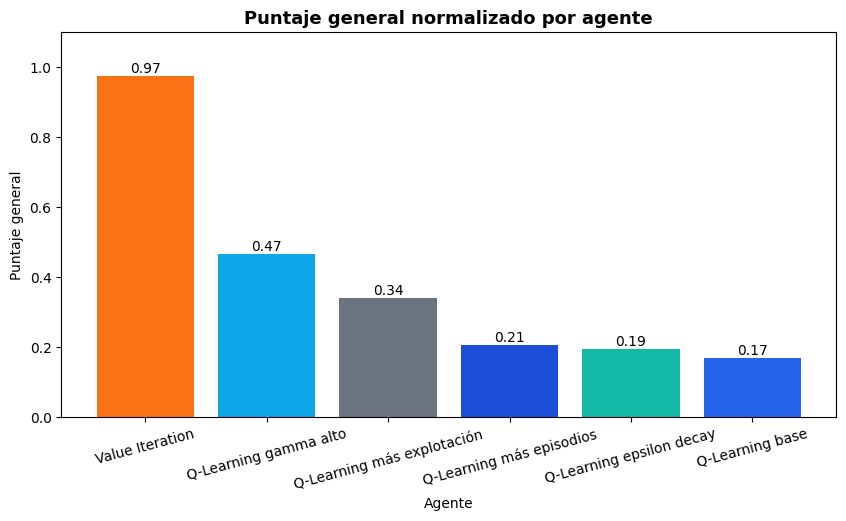

In [42]:
plt.figure(figsize=(10, 5))
colors = [agent_colors.get(agent, "#6b7280") for agent in summary_score["Agente"]]

bars = plt.bar(summary_score["Agente"], summary_score["Puntaje general"], color=colors)

plt.title("Puntaje general normalizado por agente", fontsize=13, fontweight="bold")
plt.ylabel("Puntaje general")
plt.xlabel("Agente")
plt.ylim(0, 1.1)
plt.xticks(rotation=15)

for bar, value in zip(bars, summary_score["Puntaje general"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}",
        ha="center",
        va="bottom",
    )

plt.savefig(PLOTS_DIR / "puntaje_general.png", bbox_inches="tight", dpi=150)
plt.show()

## 18. Curva de aprendizaje de la mejor versión de Q-Learning

Además de la versión base, es útil mostrar la curva de aprendizaje de la mejor configuración encontrada.

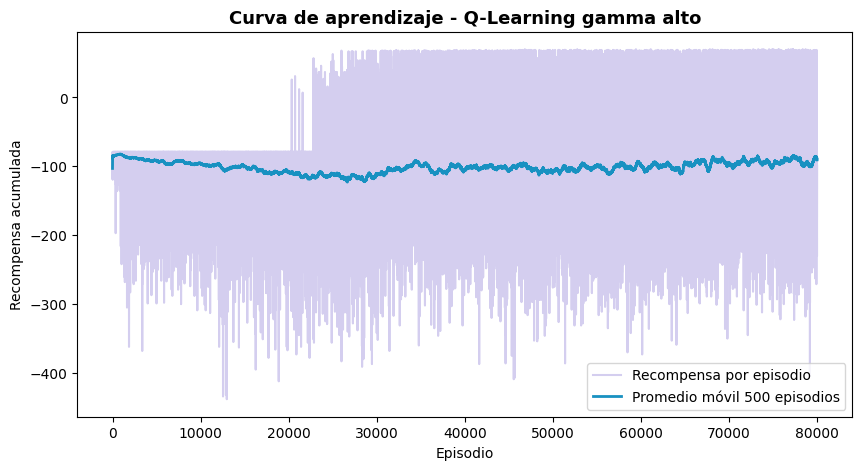

In [43]:
best_q_name = best_q["Agente"]

if best_q_name == "Q-Learning base":
    best_q_agent = ql_base
else:
    best_q_agent = q_experiment_agents[best_q_name]

best_rewards = pd.Series(best_q_agent.rewards_per_episode)
best_rolling = best_rewards.rolling(window=500, min_periods=1).mean()

plt.figure(figsize=(10, 5))
plt.plot(best_rewards, alpha=0.20, color="#290DB3", label="Recompensa por episodio")
plt.plot(best_rolling, color="#1891c1", linewidth=2, label="Promedio móvil 500 episodios")
plt.title(f"Curva de aprendizaje - {best_q_name}", fontsize=13, fontweight="bold")
plt.xlabel("Episodio")
plt.ylabel("Recompensa acumulada")
plt.legend()
plt.savefig(PLOTS_DIR / "q_learning_rewards_mejor_configuracion.png", bbox_inches="tight", dpi=150)
plt.show()

## 19. Interpretación final automática

Esta celda genera una interpretación breve usando los resultados obtenidos en la corrida actual.

In [44]:
vi_success = vi_row["% entregas exitosas"]
vi_time = vi_row["Tiempo promedio de entrega"]
vi_battery = vi_row["Consumo promedio de batería"]
vi_reward = vi_row["Recompensa acumulada promedio"]
vi_failures = vi_row["Fallos de misión"]

best_q_success = best_q["% entregas exitosas"]
best_q_time = best_q["Tiempo promedio de entrega"]
best_q_battery = best_q["Consumo promedio de batería"]
best_q_reward = best_q["Recompensa acumulada promedio"]
best_q_failures = best_q["Fallos de misión"]

print("Interpretación sugerida:")
print(f"Value Iteration obtuvo {vi_success:.1f}% de entregas exitosas, con {vi_time:.2f} pasos promedio y {vi_battery:.2f} unidades de batería consumidas.")
print(f"La mejor configuración de Q-Learning fue '{best_q_name}', con {best_q_success:.1f}% de entregas exitosas, {best_q_time:.2f} pasos promedio y {best_q_battery:.2f} unidades de batería consumidas.")
print(f"En recompensa promedio, Value Iteration obtuvo {vi_reward:.2f}, mientras que la mejor versión de Q-Learning obtuvo {best_q_reward:.2f}.")
print(f"En fallos de misión, Value Iteration tuvo {vi_failures:.0f} y la mejor versión de Q-Learning tuvo {best_q_failures:.0f}.")
print()
print("Conclusión:")

if best_q_success > vi_success:
    print("En esta corrida, Q-Learning logró superar a Value Iteration en porcentaje de éxito. Esto es interesante para discutir, pero debe interpretarse con cuidado porque el entorno es estocástico y la evaluación depende de muestras aleatorias.")
    print("Value Iteration sigue siendo el referente teórico cuando el modelo del MDP está disponible, mientras que Q-Learning demuestra que puede aprender una política competitiva mediante experiencia.")
elif best_q_success == vi_success:
    print("La mejor versión de Q-Learning igualó a Value Iteration en tasa de éxito. Esto muestra que con suficiente entrenamiento y ajuste de parámetros, Q-Learning puede acercarse mucho a una política basada en modelo.")
else:
    print("Value Iteration tuvo mejor desempeño general. Esto es esperable porque utiliza el modelo de transición del entorno para calcular una política mediante Bellman.")
    print("Q-Learning aprendió una política útil por experiencia, pero al no conocer el modelo tuvo más fallos y menor recompensa promedio.")

print("El resultado permite comparar claramente un enfoque basado en modelo contra un enfoque model-free de aprendizaje por refuerzo.")

Interpretación sugerida:
Value Iteration obtuvo 90.0% de entregas exitosas, con 28.98 pasos promedio y 26.00 unidades de batería consumidas.
La mejor configuración de Q-Learning fue 'Q-Learning gamma alto', con 77.0% de entregas exitosas, 32.45 pasos promedio y 28.65 unidades de batería consumidas.
En recompensa promedio, Value Iteration obtuvo 48.60, mientras que la mejor versión de Q-Learning obtuvo 25.17.
En fallos de misión, Value Iteration tuvo 10 y la mejor versión de Q-Learning tuvo 23.

Conclusión:
Value Iteration tuvo mejor desempeño general. Esto es esperable porque utiliza el modelo de transición del entorno para calcular una política mediante Bellman.
Q-Learning aprendió una política útil por experiencia, pero al no conocer el modelo tuvo más fallos y menor recompensa promedio.
El resultado permite comparar claramente un enfoque basado en modelo contra un enfoque model-free de aprendizaje por refuerzo.


## 20. Archivos generados

Al finalizar el notebook, deberían existir archivos en:

### Tablas

- `results/tables/metricas_comparativas.csv`
- `results/tables/detalle_value_iteration.csv`
- `results/tables/detalle_q_learning_base.csv`
- `results/tables/comparacion_completa_agentes.csv`
- `results/tables/ganador_por_metrica.csv`
- `results/tables/puntaje_general_normalizado.csv`

### Gráficas

- `results/plots/mapa_hospital.png`
- `results/plots/entregas_exitosas.png`
- `results/plots/recompensa_promedio.png`
- `results/plots/consumo_bateria.png`
- `results/plots/fallos_mision.png`
- `results/plots/tiempo_entrega.png`
- `results/plots/q_learning_rewards_base.png`
- `results/plots/comparacion_completa_entregas_exitosas.png`
- `results/plots/comparacion_completa_recompensa.png`
- `results/plots/comparacion_completa_fallos.png`
- `results/plots/puntaje_general.png`
- `results/plots/q_learning_rewards_mejor_configuracion.png`

In [45]:
print("Tablas generadas:")
for path in sorted(TABLES_DIR.glob("*.csv")):
    print("-", path.relative_to(ROOT))

print("\nGráficas generadas:")
for path in sorted(PLOTS_DIR.glob("*.png")):
    print("-", path.relative_to(ROOT))

Tablas generadas:
- results/tables/comparacion_completa_agentes.csv
- results/tables/comparacion_por_escenario.csv
- results/tables/detalle_q_learning.csv
- results/tables/detalle_q_learning_base.csv
- results/tables/detalle_value_iteration.csv
- results/tables/ganador_por_metrica.csv
- results/tables/metricas_comparativas.csv
- results/tables/puntaje_general_normalizado.csv
- results/tables/robustez_agentes.csv

Gráficas generadas:
- results/plots/comparacion_completa_entregas_exitosas.png
- results/plots/comparacion_completa_fallos.png
- results/plots/comparacion_completa_recompensa.png
- results/plots/consumo_bateria.png
- results/plots/curva_mejor_q_learning.png
- results/plots/entregas_exitosas.png
- results/plots/escenarios_bateria.png
- results/plots/escenarios_entregas_exitosas.png
- results/plots/escenarios_fallos.png
- results/plots/escenarios_recompensa.png
- results/plots/fallos_mision.png
- results/plots/mapa_base.png
- results/plots/mapa_congestionado.png
- results/plots/